# PRL Match Model Training and Full Candidate-Pair Prediction

This notebook builds the first machine learning model for the Sondondo Valley probabilistic record linkage workflow.

The goal is to train an initial model that predicts whether two `persona` records are likely to refer to the same historical person.

This notebook works at the **pair level**, not the final person-cluster level. The output is a candidate-pair file with match probabilities and prediction categories.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 1. Project Context

The original `personas.csv` file contains person mentions from baptism, marriage, and burial records. These rows are not confirmed unique people. The purpose of the PRL workflow is to identify which person mentions may refer to the same real historical individual.

Before this notebook, the following steps were completed:

1. Created a PRL-ready personas file with cleaned names, event metadata, role groups, and blocking keys.
2. Generated candidate pairs using multiple blocking rules.
3. Calculated similarity features for each candidate pair.
4. Created a balanced review sample.
5. Added provisional AI-assisted labels for initial pipeline testing.

This notebook trains initial ML models using the provisional labeled training seed.

## 2. Important Note About Labels

The labels used in this notebook are **AI-assisted provisional labels**, not final expert-confirmed historical labels.

These labels are useful for testing the machine learning pipeline and producing an initial ranked prediction file. However, the model results should not be interpreted as final historical accuracy.

The final model should be retrained and re-evaluated after expert-reviewed labels are available.

## 3. Load Training Seed Data

The training seed file contains candidate pairs that have been labeled as either:

- `match`
- `not_match`

Rows labeled as `uncertain` were removed from this training file because they are not suitable for supervised binary classification.

In [2]:
input_path = Path("../data/interim/Vamsi/candidate_pairs_training_data.csv")

training_data = pd.read_csv(input_path)

print("Training data shape:", training_data.shape)
training_data.head()

Training data shape: (1260, 69)


,persona_idno_1,persona_idno_2,blocking_rules_matched,blocking_rule_count,event_idno_1,original_identifier_1,source_event_type_1,persona_type_1,role_group_1,name_1,...,birth_year_similarity,death_year_similarity,event_year_similarity,context_similarity_score,blocking_strength_score,role_similarity_score,preliminary_match_score,preliminary_confidence_level,manual_label,reviewer_notes
0,persona-21520,persona-36495,rule1_lastname_initial|rule2_lastname_firstnam...,3,bautizo-5463,APAucará-LB-L003_B1169,Baptism,mother,family_relation,juana,...,NaN,NaN,80.0,90.0,90,100,87.6,high_confidence_candidate,match,AI-assisted provisional label: match because f...
1,persona-21520,persona-21565,rule1_lastname_initial|rule2_lastname_firstnam...,3,bautizo-5463,APAucará-LB-L003_B1169,Baptism,mother,family_relation,juana,...,NaN,NaN,100.0,100.0,90,70,87.6,high_confidence_candidate,match,AI-assisted provisional label: match because f...
2,persona-29377,persona-29450,rule1_lastname_initial|rule2_lastname_firstnam...,3,matrimonio-474,APAucará-LM-L001_M474,Marriage,witness,witness,sebastian,...,NaN,NaN,100.0,100.0,90,70,87.6,high_confidence_candidate,match,AI-assisted provisional label: match because f...
3,persona-12851,persona-37205,rule1_lastname_initial|rule2_lastname_firstnam...,3,bautizo-3281,APAucará-LB-L005_B00173,Baptism,mother,family_relation,cayetana,...,NaN,NaN,100.0,100.0,90,70,87.6,high_confidence_candidate,match,AI-assisted provisional label: match because f...
4,persona-29993,persona-32216,rule1_lastname_initial|rule2_lastname_firstnam...,3,matrimonio-534,APAucará-LM-L004_M025,Marriage,father_of_husband,family_relation,josé,...,NaN,NaN,80.0,90.0,90,100,87.6,high_confidence_candidate,match,AI-assisted provisional label: match because f...


In [3]:
training_data["manual_label"].value_counts()

manual_label
match        736
not_match    524
Name: count, dtype: int64

## 4. Feature Selection

The model is trained using similarity and context-based features.

The selected features represent different types of linkage evidence:

- Name similarity
- Gender compatibility
- Birth, death, and event-year comparison
- Place similarity
- Context similarity
- Blocking strength
- Role-group comparison

Columns such as `manual_label`, `reviewer_notes`, and `preliminary_confidence_level` are not used as model features because they are labels or derived review fields.

In [21]:
feature_columns = [
    "first_name_similarity",
    "lastname_similarity",
    "full_name_similarity",

    "gender_similarity",

    "birth_year_difference",
    "death_year_difference",
    "event_year_difference",

    "birth_year_similarity",
    "death_year_similarity",
    "event_year_similarity",

    "event_place_similarity",
    "birth_place_similarity",
    "resident_in_similarity",

    "context_similarity_score",

    "blocking_rule_count",
    "same_role_group"
]

In [22]:
missing_features = [
    col for col in feature_columns
    if col not in training_data.columns
]

if len(missing_features) == 0:
    print("All feature columns are present.")
else:
    print("Missing features:", missing_features)

All feature columns are present.


## 5. Train-Test Split

The labeled data is split into training and testing sets.

A stratified split is used so that both `match` and `not_match` labels remain proportionally represented in the training and testing data.

This allows the model evaluation to be more balanced and reliable.

In [23]:
X = training_data[feature_columns].copy()

y = training_data["manual_label"].map({
    "not_match": 0,
    "match": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (1260, 16)
y shape: (1260,)

Target distribution:
manual_label
1    736
0    524
Name: count, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 945
Testing rows: 315


In [25]:
print(training_data.shape)
print(training_data["manual_label"].value_counts())
print(missing_features)
print(X_train.shape)
print(X_test.shape)

(1260, 69)
manual_label
match        736
not_match    524
Name: count, dtype: int64
[]
(945, 16)
(315, 16)


## 6. Logistic Regression Model

Logistic Regression is used as the first baseline model.

This model is useful because it is simple, explainable, and works well for binary classification problems.

In this project, Logistic Regression predicts:

- `0` = not_match
- `1` = match

In [26]:
logistic_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Evaluate Logistic Regression

In [27]:
logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy:", accuracy_score(y_test, logistic_predictions))
print("Precision:", precision_score(y_test, logistic_predictions))
print("Recall:", recall_score(y_test, logistic_predictions))
print("F1 Score:", f1_score(y_test, logistic_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    logistic_predictions,
    target_names=["not_match", "match"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_predictions))

Logistic Regression Results
---------------------------
Accuracy: 0.9968253968253968
Precision: 0.9945945945945946
Recall: 1.0
F1 Score: 0.997289972899729

Classification Report:
              precision    recall  f1-score   support

   not_match       1.00      0.99      1.00       131
       match       0.99      1.00      1.00       184

    accuracy                           1.00       315
   macro avg       1.00      1.00      1.00       315
weighted avg       1.00      1.00      1.00       315


Confusion Matrix:
[[130   1]
 [  0 184]]


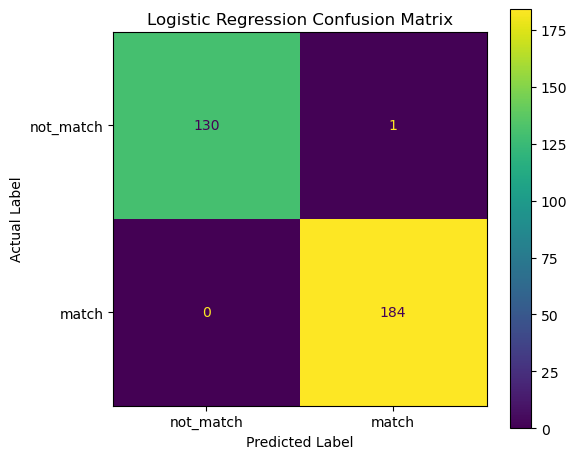

In [36]:

cm = confusion_matrix(y_test, logistic_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["not_match", "match"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

## 7. Random Forest Model

Random Forest is trained as a second model for comparison.

Unlike Logistic Regression, Random Forest can capture non-linear relationships between features. It is also useful for checking feature importance and understanding which linkage signals are most influential.

In [28]:
random_forest_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [29]:
rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("---------------------")
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall:", recall_score(y_test, rf_predictions))
print("F1 Score:", f1_score(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_predictions,
    target_names=["not_match", "match"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Results
---------------------
Accuracy: 0.9936507936507937
Precision: 0.9945652173913043
Recall: 0.9945652173913043
F1 Score: 0.9945652173913043

Classification Report:
              precision    recall  f1-score   support

   not_match       0.99      0.99      0.99       131
       match       0.99      0.99      0.99       184

    accuracy                           0.99       315
   macro avg       0.99      0.99      0.99       315
weighted avg       0.99      0.99      0.99       315


Confusion Matrix:
[[130   1]
 [  1 183]]


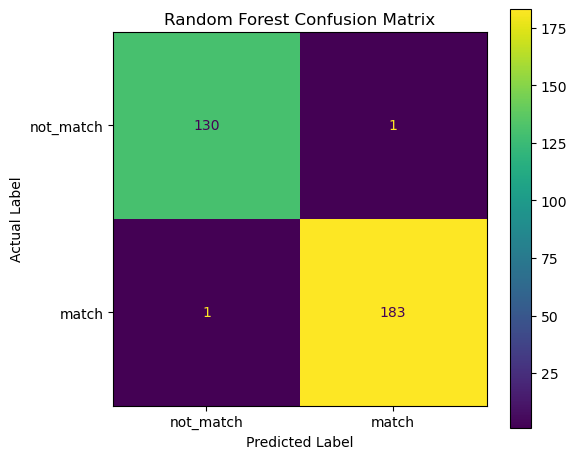

In [37]:
cm_rf = confusion_matrix(y_test, rf_predictions)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["not_match", "match"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(ax=ax, values_format="d")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [33]:
rf_model = random_forest_model.named_steps["model"]

rf_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_importance.head(10)

,feature,importance
2,full_name_similarity,0.365897
14,blocking_rule_count,0.300385
0,first_name_similarity,0.200704
13,context_similarity_score,0.046436
3,gender_similarity,0.030478
6,event_year_difference,0.028292
9,event_year_similarity,0.015699
10,event_place_similarity,0.008400
1,lastname_similarity,0.001607
15,same_role_group,0.001338


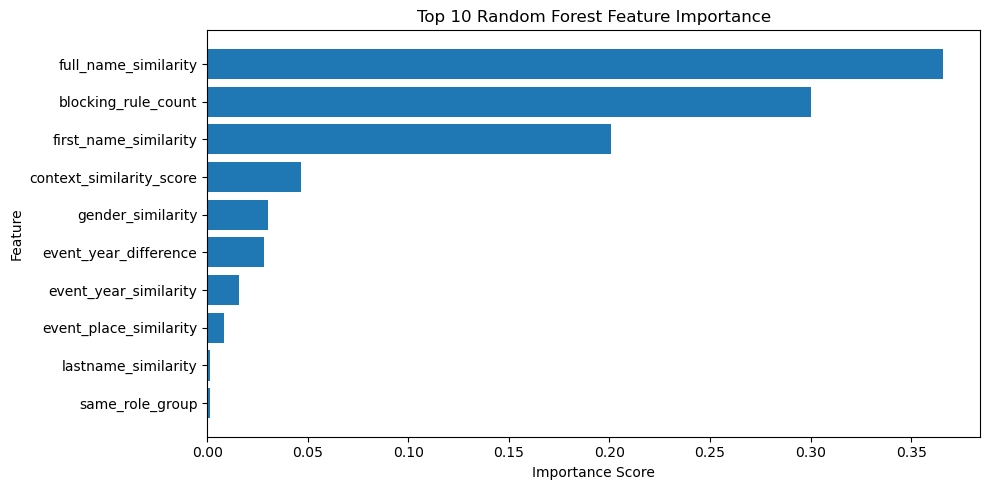

In [34]:
top_features = rf_importance.head(10)

plt.figure(figsize=(10, 5))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importance")

plt.tight_layout()
plt.show()

## 8. Model Evaluation

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Classification report
- Confusion matrix

For this record linkage task, precision is especially important because a false positive means two different historical people may be incorrectly merged.

In [14]:
model_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, logistic_predictions),
        "precision": precision_score(y_test, logistic_predictions),
        "recall": recall_score(y_test, logistic_predictions),
        "f1_score": f1_score(y_test, logistic_predictions)
    },
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, rf_predictions),
        "precision": precision_score(y_test, rf_predictions),
        "recall": recall_score(y_test, rf_predictions),
        "f1_score": f1_score(y_test, rf_predictions)
    }
])

model_results

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.996825,0.994595,1.000000,0.997290
1,Random Forest,0.993651,0.994565,0.994565,0.994565


I am going to choose logistic regression for now
why?
1. It has slightly better accuracy.
2. It has perfect recall on this test split.
3. Precision is almost the same as Random Forest.
4. It is easier to explain to your professor.
5. It works well for a first PRL model.

In [15]:
import joblib
from pathlib import Path

model_output_dir = Path("../data/interim/Vamsi/models")

model_output_dir.mkdir(parents=True, exist_ok=True)

model_output_path = model_output_dir / "prl_logistic_regression_match_model.joblib"

joblib.dump(logistic_model, model_output_path)

print("Saved Logistic Regression model to:", model_output_path)

Saved Logistic Regression model to: ..\data\interim\Vamsi\models\prl_logistic_regression_match_model.joblib


## 9. Apply Model to Full Candidate-Pair Dataset

After training and evaluating the model, the selected model is applied to the full candidate-pair dataset.

The full prediction output includes:

- All candidate pairs
- Match probability
- ML prediction category

This output is still pair-level prediction. It does not yet create final `unique_person_id` clusters.

In [16]:
full_input_path = Path("../data/interim/Vamsi/candidate_pairs_similarity_final.parquet")

candidate_pairs_full = pd.read_parquet(full_input_path)

X_full = candidate_pairs_full[feature_columns].copy()

candidate_pairs_full["match_probability"] = logistic_model.predict_proba(X_full)[:, 1]

candidate_pairs_full[[
    "persona_idno_1",
    "persona_idno_2",
    "match_probability"
]].head()

c:\Users\samav\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['death_place_similarity']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,persona_idno_1,persona_idno_2,match_probability
0,persona-10,persona-10078,0.000009
1,persona-10,persona-1008,0.000005
2,persona-10,persona-10081,0.000012
3,persona-10,persona-10320,0.000026
4,persona-10,persona-10366,0.000014


prediction categories:

In [17]:
def assign_ml_prediction(probability):
    if probability >= 0.90:
        return "likely_match"
    elif probability >= 0.70:
        return "needs_review"
    else:
        return "likely_not_match"


candidate_pairs_full["ml_prediction"] = candidate_pairs_full["match_probability"].apply(
    assign_ml_prediction
)

candidate_pairs_full["ml_prediction"].value_counts()

ml_prediction
likely_not_match    1084972
likely_match         165437
needs_review           7315
Name: count, dtype: int64

save

In [18]:
ml_output_path = Path("../data/interim/Vamsi/candidate_pairs_ml_predictions.parquet")

candidate_pairs_full.to_parquet(ml_output_path, index=False)

print("Saved ML prediction file to:", ml_output_path)
print("Final shape:", candidate_pairs_full.shape)

Saved ML prediction file to: ..\data\interim\Vamsi\candidate_pairs_ml_predictions.parquet
Final shape: (1257724, 69)


## 10. Summary

In this notebook:

1. Loaded the provisional labeled training seed.
2. Selected similarity and context features.
3. Trained Logistic Regression and Random Forest models.
4. Compared model performance.
5. Reviewed confusion matrix results.
6. Checked Random Forest feature importance.
7. Applied the selected model to the full candidate-pair dataset.
8. Created a full prediction file with match probabilities.

The current output supports review and threshold selection before moving to final person clustering.